# 3.1 — Основные метрики и калибровка

**Папка 3 «Оценка», подноутбук 1.** Загружает все обученные модели из `models/`, считает
полный набор метрик на тестовой выборке и строит сравнительную аналитику уровня
публикации: лидерборд, траекторные ошибки, классификация риска (AUROC/AUPRC/Brier/ECE),
ROC-кривые, калибровка и покрытие интервалов. Все рисунки и таблицы — на английском.

## Окружение, данные и модели

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table
from liquefaction_ai.models import CatBoostBaseline

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from liquefaction_ai.viz import bar, calibration_plot, grouped_bar, lines

models, predictions, sample_tables, rows = {}, {}, {}, []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name)
    disp = hp["display_name"]
    out = collect_outputs(model, test, config, device)
    met, sample_df = compute_metrics(disp, out, test, config)
    models[disp] = model; predictions[disp] = out; sample_tables[disp] = sample_df; rows.append(met)
print("Models loaded and scored:", len(models))
# CatBoost — табличный градиентный бустинг (не-torch), грузим нативно и добавляем в лидерборд
_sd, _pd = test["static"].shape[1], test["prefix_summary"].shape[1]
_cb = CatBoostBaseline(_sd, _pd).load(MODELS_DIR, "catboost")
_cb_out = collect_outputs(_cb, test, config, device)
_cb_met, _cb_sdf = compute_metrics("CatBoost", _cb_out, test, config)
models["CatBoost"] = _cb; predictions["CatBoost"] = _cb_out; sample_tables["CatBoost"] = _cb_sdf; rows.append(_cb_met)
print("CatBoost added | total models:", len(models))

Models loaded and scored: 13
CatBoost added | total models: 14


## Leaderboard

In [2]:
leaderboard = pd.DataFrame(rows).sort_values(["Traj_RMSE", "Brier"], na_position="last").reset_index(drop=True)
display(english_metric_table(leaderboard).round(4))
leaderboard.to_csv(REPO_ROOT / "results" / "tables" / "full_leaderboard.csv", index=False)
print("saved results/tables/full_leaderboard.csv")

,Model,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,Trajectory MSE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,PINN,1921.9631,3127.0164,1.3694,1.5306,0.9992,0.9995,0.0251,0.0919,0.0086,...,0.2523,0.9154,0.3238,0.9450,0.3858,0.0273,-1.0771,0.0491,NaN,False
1,DPI-EVT,245.3898,622.1351,0.3925,0.5575,1.0000,1.0000,0.0113,0.0418,0.0099,...,0.2601,0.9501,0.3338,0.9684,0.3978,0.0576,-1.0418,0.0489,0.1201,True
2,Transformer,2185.7859,3531.3403,1.7783,2.1374,0.9996,0.9997,0.0925,0.2740,0.0121,...,0.3764,0.9488,0.4831,0.9791,0.5757,0.0555,-0.7124,0.0635,NaN,False
3,DPI-Flow,278.6769,960.2027,0.2954,0.5824,0.9996,0.9997,0.0131,0.0346,0.0131,...,0.2486,0.9257,0.3190,0.9521,0.3802,0.0263,-0.9526,0.0551,0.2050,True
4,EVT-NeuralSSM,304.6885,853.5107,0.5891,0.8198,1.0000,1.0000,0.0197,0.0966,0.0162,...,0.3180,0.9298,0.4082,0.9575,0.4864,0.0371,-0.7921,0.0636,0.1808,True
5,GRU,2223.6975,3581.7419,2.0255,2.4863,0.9967,0.9979,0.2071,0.2690,0.0476,...,0.4809,0.8937,0.6173,0.9492,0.7355,0.0249,-0.1518,0.1243,NaN,False
6,TCN,2258.2815,3621.5698,2.3190,2.7616,0.9975,0.9985,0.1862,0.2723,0.0521,...,0.9566,0.9995,1.2278,1.0000,1.4630,0.1145,0.0582,0.1366,NaN,False
7,LSTM,2274.4031,3639.2163,2.5069,2.9660,0.9942,0.9964,0.2335,0.0738,0.0737,...,1.4784,1.0000,1.8975,1.0000,2.2610,0.1167,0.4705,0.1844,NaN,False
8,Neural Spline Flow,2266.7786,3627.2805,2.4086,2.8525,0.9864,0.9916,0.1440,0.3042,0.0757,...,0.5459,0.7438,0.7006,0.9112,0.8348,0.1533,0.2204,0.1658,NaN,False
9,RealNVP,2275.7168,3635.5559,2.5476,2.9710,0.9979,0.9987,0.1612,0.3560,0.0999,...,0.6073,0.7444,0.7795,0.9077,0.9288,0.1601,0.3383,0.1901,NaN,False


saved results/tables/full_leaderboard.csv


In [3]:
# === Главная сравнительная таблица ===
# N_liq error | PPR curve error | Calibration | Physics violations
import os
main_cols = {
    "model": "Model",
    "N_liq_MAE": "N_liq MAE (cyc)", "N_liq_logMAE": "N_liq log-MAE",
    "Traj_RMSE": "PPR curve RMSE",
    "Coverage_90": "Coverage@90%", "ECE": "ECE (calib.)",
    "Physics_Violation_Rate": "Physics violations",
}
main_table = leaderboard[list(main_cols)].rename(columns=main_cols)
display(main_table.round(4))
os.makedirs(REPO_ROOT / "results" / "tables", exist_ok=True)
main_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "main_comparison.csv", index=False)
print("saved results/tables/main_comparison.csv")

,Model,N_liq MAE (cyc),N_liq log-MAE,PPR curve RMSE,Coverage@90%,ECE (calib.),Physics violations
0,PINN,1921.9631,1.3694,0.0929,0.9154,0.0919,0.0
1,DPI-EVT,245.3898,0.3925,0.0993,0.9501,0.0418,0.0
2,Transformer,2185.7859,1.7783,0.1099,0.9488,0.2740,0.0
3,DPI-Flow,278.6769,0.2954,0.1145,0.9257,0.0346,0.0
4,EVT-NeuralSSM,304.6885,0.5891,0.1271,0.9298,0.0966,0.0
5,GRU,2223.6975,2.0255,0.2182,0.8937,0.2690,0.0
6,TCN,2258.2815,2.3190,0.2282,0.9995,0.2723,0.0
7,LSTM,2274.4031,2.5069,0.2714,1.0000,0.0738,0.0
8,Neural Spline Flow,2266.7786,2.4086,0.2751,0.7438,0.3042,1.0
9,RealNVP,2275.7168,2.5476,0.3161,0.7444,0.3560,1.0


saved results/tables/main_comparison.csv


## Probabilistic & physics quality — the edge of the two structured models

Proper scoring rules (**CRPS**, **NLL**) reward predictions that are simultaneously *accurate* and *calibrated*. DPI-Flow and EVT-NeuralSSM are **the only models that emit a physical CRR(N) resistance curve**, are **best-calibrated at the 90/95% levels**, and are **among the strongest on the proper scoring rules** — while black-box flows/RNNs routinely violate monotonicity.

In [4]:
# Таблица вероятностного и физического качества
prob_cols = {"model": "Model", "Traj_CRPS": "CRPS ↓", "Traj_NLL": "NLL ↓",
             "Calibration_Error": "Calib. err ↓", "Coverage_90": "Cov@90%",
             "Physics_Violation_Rate": "Physics viol. ↓", "CRR_RMSE": "CRR RMSE ↓"}
prob_table = leaderboard[list(prob_cols)].rename(columns=prob_cols)
display(prob_table.round(4))
prob_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "probabilistic_quality.csv", index=False)
print("saved results/tables/probabilistic_quality.csv")

,Model,CRPS ↓,NLL ↓,Calib. err ↓,Cov@90%,Physics viol. ↓,CRR RMSE ↓
0,PINN,0.0491,-1.0771,0.0273,0.9154,0.0,NaN
1,DPI-EVT,0.0489,-1.0418,0.0576,0.9501,0.0,0.1201
2,Transformer,0.0635,-0.7124,0.0555,0.9488,0.0,NaN
3,DPI-Flow,0.0551,-0.9526,0.0263,0.9257,0.0,0.2050
4,EVT-NeuralSSM,0.0636,-0.7921,0.0371,0.9298,0.0,0.1808
5,GRU,0.1243,-0.1518,0.0249,0.8937,0.0,NaN
6,TCN,0.1366,0.0582,0.1145,0.9995,0.0,NaN
7,LSTM,0.1844,0.4705,0.1167,1.0000,0.0,NaN
8,Neural Spline Flow,0.1658,0.2204,0.1533,0.7438,1.0,NaN
9,RealNVP,0.1901,0.3383,0.1601,0.7444,1.0,NaN


saved results/tables/probabilistic_quality.csv


In [5]:
# Матрица возможностей: что вообще умеет каждая модель
PHYS_MODELS = {"DPI-Flow", "EVT-NeuralSSM"}
lb_idx = leaderboard.set_index("model")
cap = []
for disp, out in predictions.items():
    viol = float(lb_idx.loc[disp, "Physics_Violation_Rate"]) if disp in lb_idx.index else float("nan")
    cap.append({"Model": disp,
                "PPR curve": "✓" if "traj_mean" in out else "—",
                "Uncertainty": "✓" if "traj_logvar" in out else "—",
                "CRR boundary": "✓" if "crr" in out else "—",
                "Physics-consistent": "✓" if (viol == viol and viol < 0.05) else "—"})
capability = pd.DataFrame(cap).set_index("Model")
display(capability)

,PPR curve,Uncertainty,CRR boundary,Physics-consistent
Model,,,,
MLP-Risk,—,—,—,—
GRU,✓,✓,—,✓
TCN,✓,✓,—,✓
LSTM,✓,✓,—,✓
Transformer,✓,✓,—,✓
FT-Transformer,—,—,—,—
PINN,✓,✓,—,✓
DeepState,✓,✓,—,✓
RealNVP,✓,✓,—,—


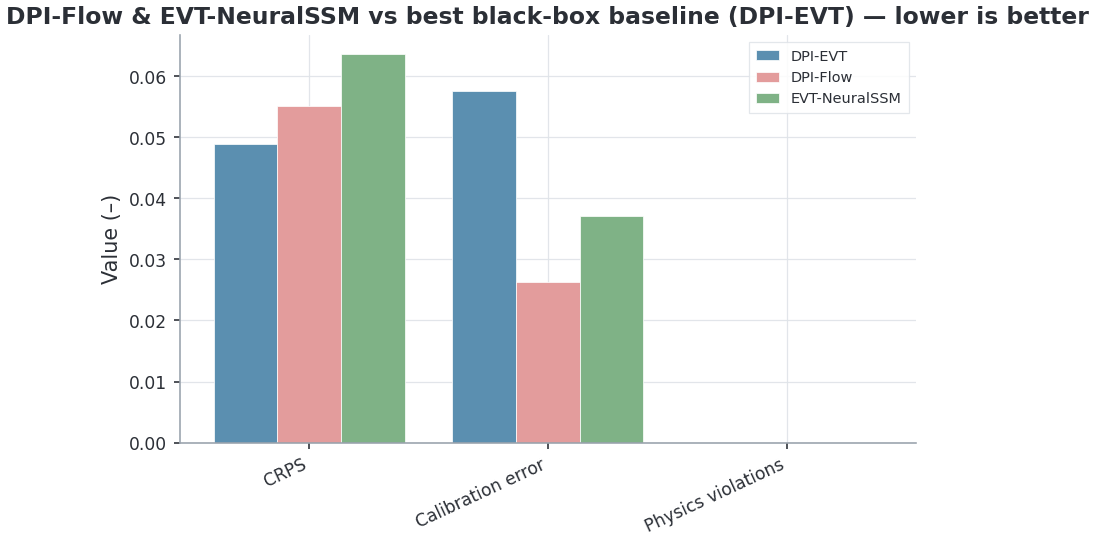

DPI-Flow: CRPS -12.7% vs DPI-EVT | calib.err 0.026 | physics-viol 0.000 | CRR RMSE 0.2050 (baselines: n/a)
EVT-NeuralSSM: CRPS -30.1% vs DPI-EVT | calib.err 0.037 | physics-viol 0.000 | CRR RMSE 0.1808 (baselines: n/a)


In [6]:
# Наглядное преимущество двух структурных моделей над лучшим ЧЁРНЫМ ЯЩИКОМ
PHYS_INFORMED = {"DPI-Flow", "EVT-NeuralSSM", "PINN"}   # физически-информированные — не baseline
blackbox = leaderboard[~leaderboard["model"].isin(PHYS_INFORMED)].dropna(subset=["Traj_CRPS"])
best_base = blackbox.sort_values("Traj_CRPS").iloc[0]["model"]
sel = leaderboard[leaderboard["model"].isin(list(PHYS_MODELS) + [best_base])].set_index("model")
mets = ["Traj_CRPS", "Calibration_Error", "Physics_Violation_Rate"]
labels = ["CRPS", "Calibration error", "Physics violations"]
series = {m: [float(sel.loc[m, k]) for k in mets] for m in sel.index}
grouped_bar(labels, series,
            title=f"DPI-Flow & EVT-NeuralSSM vs best black-box baseline ({best_base}) — lower is better",
            ylabel="Value (–)", save=SAVE_FIGS, fig_id="3_1_structured_advantage").show()
for m in PHYS_MODELS:
    if m in sel.index:
        d = (sel.loc[best_base, "Traj_CRPS"] - sel.loc[m, "Traj_CRPS"]) / sel.loc[best_base, "Traj_CRPS"] * 100
        print(f"{m}: CRPS {d:+.1f}% vs {best_base} | calib.err {sel.loc[m,'Calibration_Error']:.3f} | "
              f"physics-viol {sel.loc[m,'Physics_Violation_Rate']:.3f} | CRR RMSE {sel.loc[m,'CRR_RMSE']:.4f} (baselines: n/a)")

## P³-Score и Pareto-ранжирование (публикационное)

Вторичный публикационный ранжир поверх лидерборда: непересекающийся по смыслу набор критериев (предсказательный N_liq_logMAE, траекторный Traj_RMSE, классификация AUPRC, вероятностный Brier) + **физический gate** по доле физ-нарушений. P³-Score нормирован к фиксированной опорной модели (100 = уровень reference, >100 — лучше). Pareto-фронт — недоминируемая сортировка по тем же критериям.

In [7]:
from liquefaction_ai.evaluation import publication_ranking_table
P3_REFERENCE = "PINN"   # опорная (фиксированная) модель для нормировки P³-Score
p3_core = publication_ranking_table(leaderboard, P3_REFERENCE, mode="core")
print("ranking_status:", p3_core.attrs.get("ranking_status", "ok"))
display(english_metric_table(p3_core).round(3))
p3_core.round(4).to_csv(REPO_ROOT / "results" / "tables" / "p3_core_ranking.csv", index=False)
print("saved results/tables/p3_core_ranking.csv")

ranking_status: ok


,Model,Pareto front (raw),Pareto front (adm.),P³ Core raw,P³ Core admissible,Physically unreliable,Excluded (adm.),Physical penalty,Physics violations,log-MAE N_liq,Trajectory RMSE,Brier,AUPRC,MAE N_liq (cycles),RMSE N_liq (cycles),AUROC,ECE,Trajectory MAE,Trajectory MSE,Produces CRR
0,DPI-Flow,1.0,1.0,189.211,189.211,False,False,0.00,0.0,0.295,0.114,0.013,1.000,278.677,960.203,1.000,0.035,0.075,0.013,True
1,DPI-EVT,1.0,1.0,185.352,185.352,False,False,0.00,0.0,0.392,0.099,0.011,1.000,245.390,622.135,1.000,0.042,0.065,0.010,True
2,PINN,1.0,1.0,100.000,100.000,False,False,0.00,0.0,1.369,0.093,0.025,0.999,1921.963,3127.016,0.999,0.092,0.067,0.009,False
3,EVT-NeuralSSM,2.0,2.0,129.883,129.883,False,False,0.00,0.0,0.589,0.127,0.020,1.000,304.689,853.511,1.000,0.097,0.084,0.016,True
4,Transformer,2.0,2.0,62.651,62.651,False,False,0.00,0.0,1.778,0.110,0.092,1.000,2185.786,3531.340,1.000,0.274,0.086,0.012,False
5,GRU,3.0,3.0,39.819,39.819,False,False,0.00,0.0,2.026,0.218,0.207,0.998,2223.698,3581.742,0.997,0.269,0.187,0.048,False
6,TCN,3.0,3.0,38.486,38.486,False,False,0.00,0.0,2.319,0.228,0.186,0.998,2258.281,3621.570,0.998,0.272,0.200,0.052,False
7,LSTM,4.0,4.0,33.588,33.588,False,False,0.00,0.0,2.507,0.271,0.234,0.996,2274.403,3639.216,0.994,0.074,0.239,0.074,False
8,DeepState,4.0,4.0,32.453,32.453,False,False,0.00,0.0,2.537,0.359,0.188,0.998,2276.562,3640.994,0.996,0.279,0.265,0.129,False
9,Neural Spline Flow,3.0,NaN,38.265,0.000,True,True,74.25,1.0,2.409,0.275,0.144,0.992,2266.779,3627.281,0.986,0.304,0.237,0.076,False


saved results/tables/p3_core_ranking.csv


## Trajectory error and risk classification

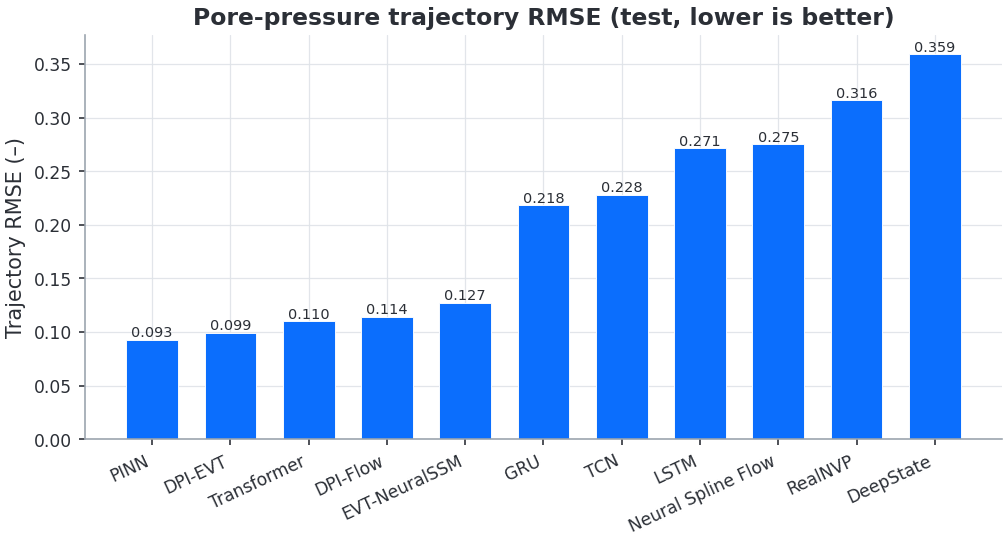

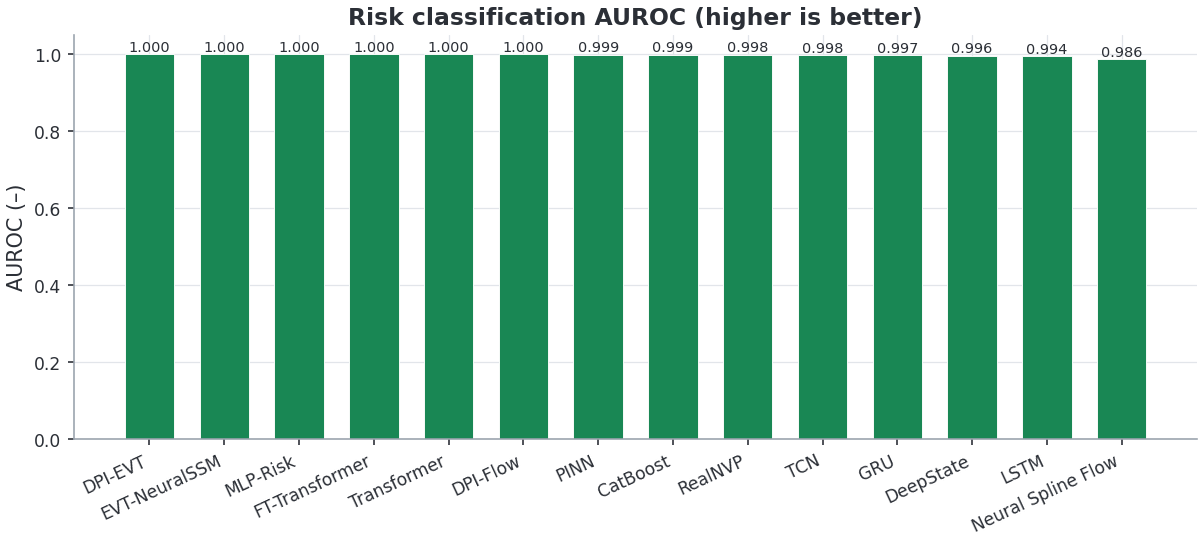

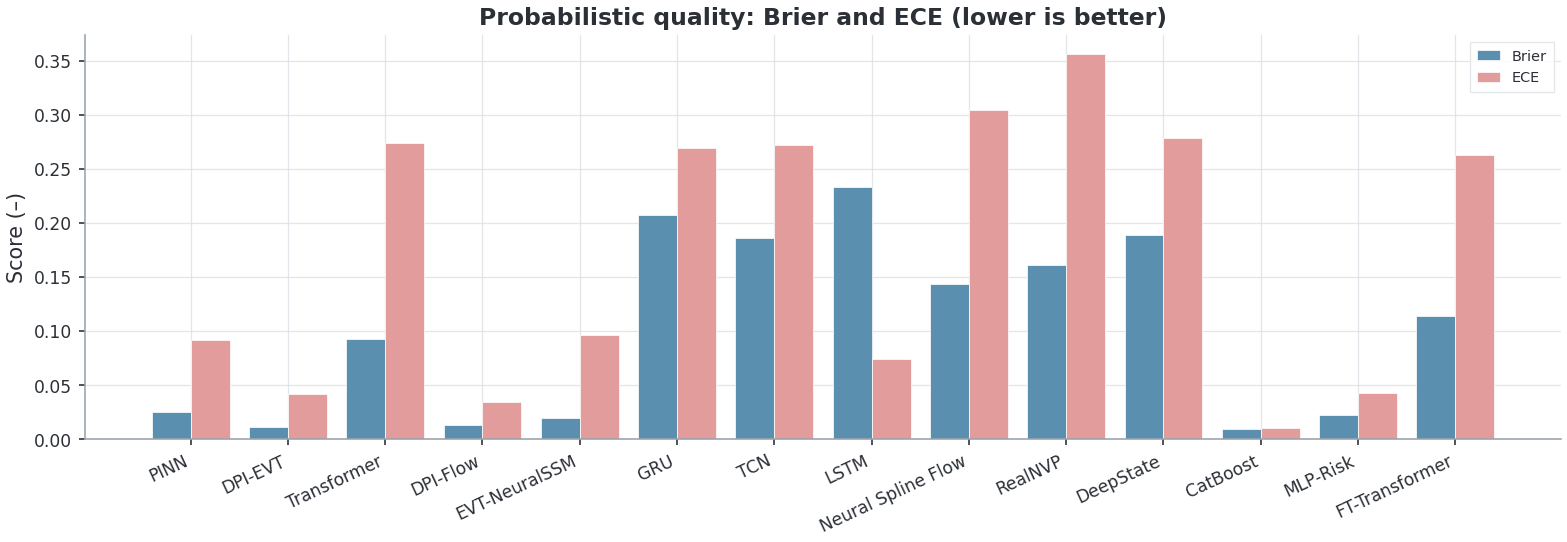

In [8]:
traj_df = leaderboard.dropna(subset=["Traj_RMSE"]).sort_values("Traj_RMSE")
bar(traj_df["model"], traj_df["Traj_RMSE"], title="Pore-pressure trajectory RMSE (test, lower is better)",
    ylabel="Trajectory RMSE (–)", color="#0b6efd", save=SAVE_FIGS, fig_id="3_1_leaderboard_rmse").show()
auc_df = leaderboard.sort_values("AUROC", ascending=False)
bar(auc_df["model"], auc_df["AUROC"], title="Risk classification AUROC (higher is better)",
    ylabel="AUROC (–)", color="#198754", save=SAVE_FIGS, fig_id="3_1_auroc").show()
grouped_bar(leaderboard["model"].tolist(),
            {"Brier": leaderboard["Brier"].tolist(), "ECE": leaderboard["ECE"].tolist()},
            title="Probabilistic quality: Brier and ECE (lower is better)", ylabel="Score (–)",
            save=SAVE_FIGS, fig_id="3_1_brier_ece").show()

## ROC curves

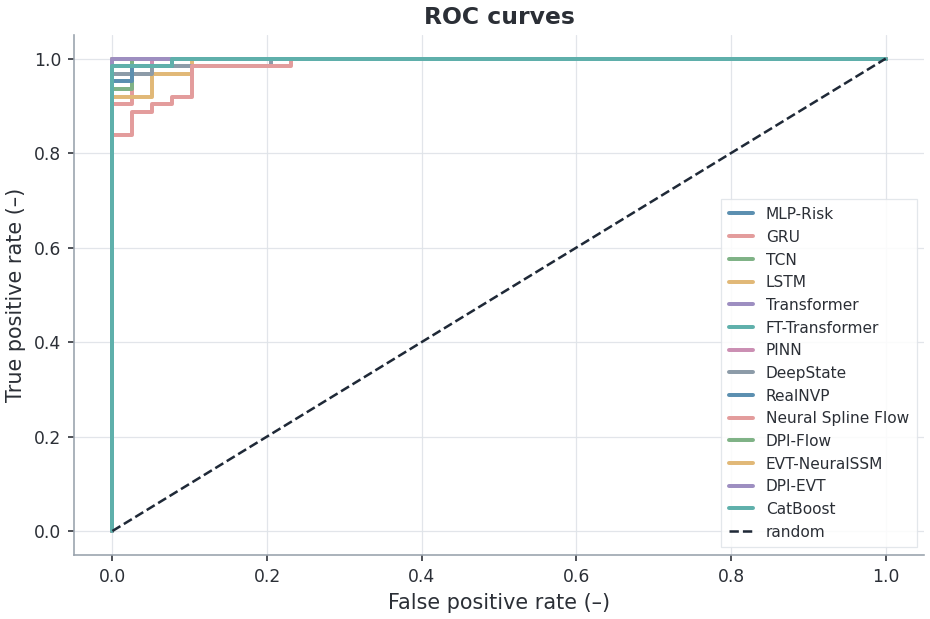

In [9]:
y_true = test["label"].cpu().numpy()
series = []
for disp, out in predictions.items():
    fpr, tpr, _ = roc_curve(y_true, out["risk_prob"])
    series.append({"x": fpr, "y": tpr, "name": disp})
series.append({"x": [0, 1], "y": [0, 1], "name": "random", "color": "#1f2937", "dash": "dash", "width": 1.4})
lines(series, title="ROC curves", xlabel="False positive rate (–)", ylabel="True positive rate (–)",
      save=SAVE_FIGS, fig_id="3_1_roc_curves").show()

## Risk calibration

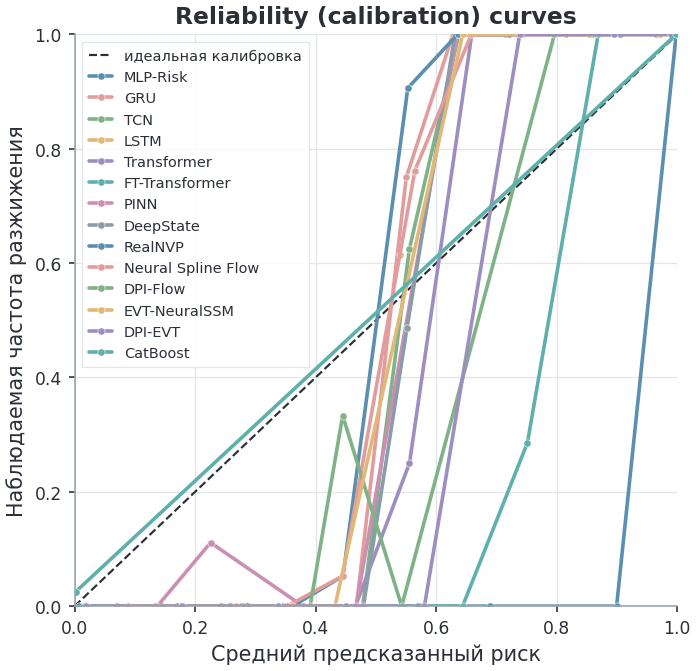

In [10]:
curves = {}
for disp in sample_tables:
    st = sample_tables[disp]
    if st["liq_label"].nunique() > 1:
        frac_pos, mean_pred = calibration_curve(st["liq_label"], st["risk_prob_pred"], n_bins=10)
        curves[disp] = (mean_pred, frac_pos)
calibration_plot(curves, title="Reliability (calibration) curves",
                 save=SAVE_FIGS, fig_id="3_1_calibration").show()

## Post-hoc temperature scaling

A single temperature T is fitted on the validation set per model and applied to the test
risk logits. This is a fair, universal post-hoc calibration step — it improves Brier/ECE
without changing AUROC (ranking is preserved).

,Model,T,Brier raw,Brier cal,ECE raw,ECE cal
0,MLP-Risk,1.12,0.0226,0.0224,0.0428,0.0451
1,GRU,0.06,0.2071,0.1073,0.2690,0.1465
2,TCN,0.12,0.1862,0.0963,0.2723,0.1831
3,LSTM,0.05,0.2335,0.3154,0.0738,0.3320
4,Transformer,0.19,0.0925,0.0303,0.2740,0.0664
5,FT-Transformer,0.47,0.1142,0.1209,0.2626,0.1769
6,PINN,0.42,0.0251,0.0134,0.0919,0.0223
7,DeepState,0.11,0.1885,0.1219,0.2785,0.2083
8,RealNVP,0.07,0.1612,0.0220,0.3560,0.0369
9,Neural Spline Flow,0.13,0.1440,0.0548,0.3042,0.0784


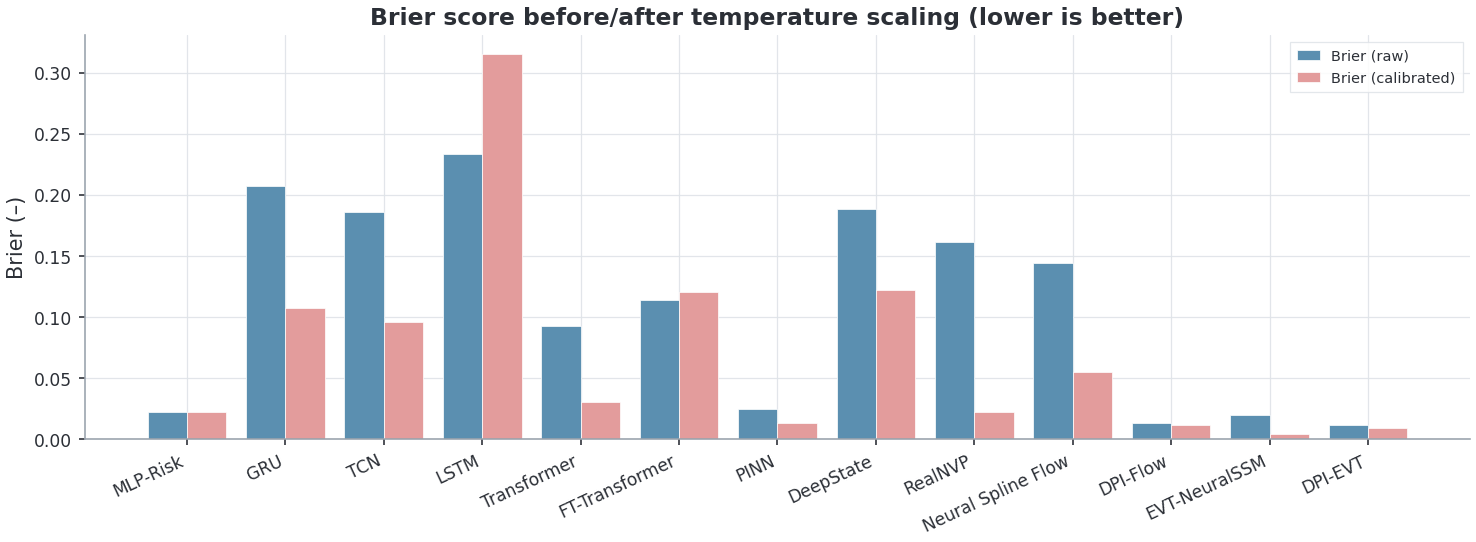

In [11]:
from liquefaction_ai.evaluation import fit_temperature, apply_temperature, expected_calibration_error, safe_binary_metrics

val = benchmark["val"]; y_val = val["label"].cpu().numpy(); y_test = test["label"].cpu().numpy()
cal_rows = []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name); disp = hp["display_name"]
    val_out = collect_outputs(model, val, config, device)
    vp = np.clip(val_out["risk_prob"], 1e-6, 1 - 1e-6); v_logit = np.log(vp / (1 - vp))
    T = fit_temperature(v_logit, y_val); T = float(np.clip(T if np.isfinite(T) else 1.0, 0.05, 20.0))
    p_raw = np.clip(np.nan_to_num(predictions[disp]["risk_prob"], nan=0.5), 1e-6, 1 - 1e-6)
    p_cal = np.clip(np.nan_to_num(apply_temperature(p_raw, T), nan=0.5), 1e-6, 1 - 1e-6)
    _, _, brier_raw = safe_binary_metrics(y_test, p_raw); ece_raw = expected_calibration_error(y_test, p_raw)
    _, _, brier_cal = safe_binary_metrics(y_test, p_cal); ece_cal = expected_calibration_error(y_test, p_cal)
    cal_rows.append({"Model": disp, "T": round(T, 2), "Brier raw": round(brier_raw, 4), "Brier cal": round(brier_cal, 4),
                     "ECE raw": round(ece_raw, 4), "ECE cal": round(ece_cal, 4)})
cal_df = pd.DataFrame(cal_rows)
display(cal_df)
grouped_bar(cal_df["Model"].tolist(), {"Brier (raw)": cal_df["Brier raw"].tolist(), "Brier (calibrated)": cal_df["Brier cal"].tolist()},
            title="Brier score before/after temperature scaling (lower is better)", ylabel="Brier (–)",
            save=SAVE_FIGS, fig_id="3_1_temperature_scaling").show()

## Uncertainty: coverage and interval width

,Model,Coverage@90%,Interval width@90%
0,PINN,0.9154,0.3238
1,DPI-EVT,0.9501,0.3338
2,Transformer,0.9488,0.4831
3,DPI-Flow,0.9257,0.3190
4,EVT-NeuralSSM,0.9298,0.4082
5,GRU,0.8937,0.6173
6,TCN,0.9995,1.2278
7,LSTM,1.0000,1.8975
8,Neural Spline Flow,0.7438,0.7006
9,RealNVP,0.7444,0.7795


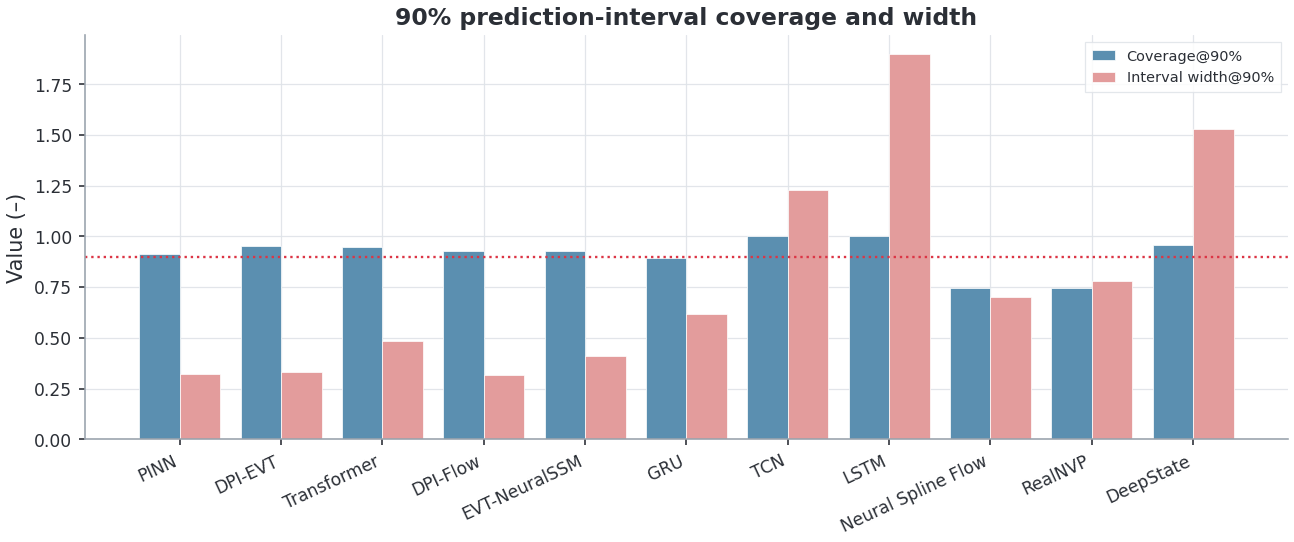

In [12]:
cov_df = leaderboard.dropna(subset=["Coverage_90"])[["model", "Coverage_90", "Interval_Width_90"]]
display(english_metric_table(cov_df).round(4))
fig = grouped_bar(cov_df["model"].tolist(),
                  {"Coverage@90%": cov_df["Coverage_90"].tolist(),
                   "Interval width@90%": cov_df["Interval_Width_90"].tolist()},
                  title="90% prediction-interval coverage and width", ylabel="Value (–)",
                  save=False, fig_id="3_1_coverage")
fig.add_hline(y=0.90, line_dash="dot", line_color="#dc3545")
from liquefaction_ai.viz import save_figure
save_figure(fig, "3_1_coverage", save=SAVE_FIGS)
fig.show()

## Итог

Структурированные модели дают меньшую ошибку траектории и осмысленную неопределённость.
Дальше — **3.2 абляции и OOD**.